ABM – Excitable Media (Christensen et al. 2015)

[1/3] Regime C – Healthy tissue (ν = 0.9)


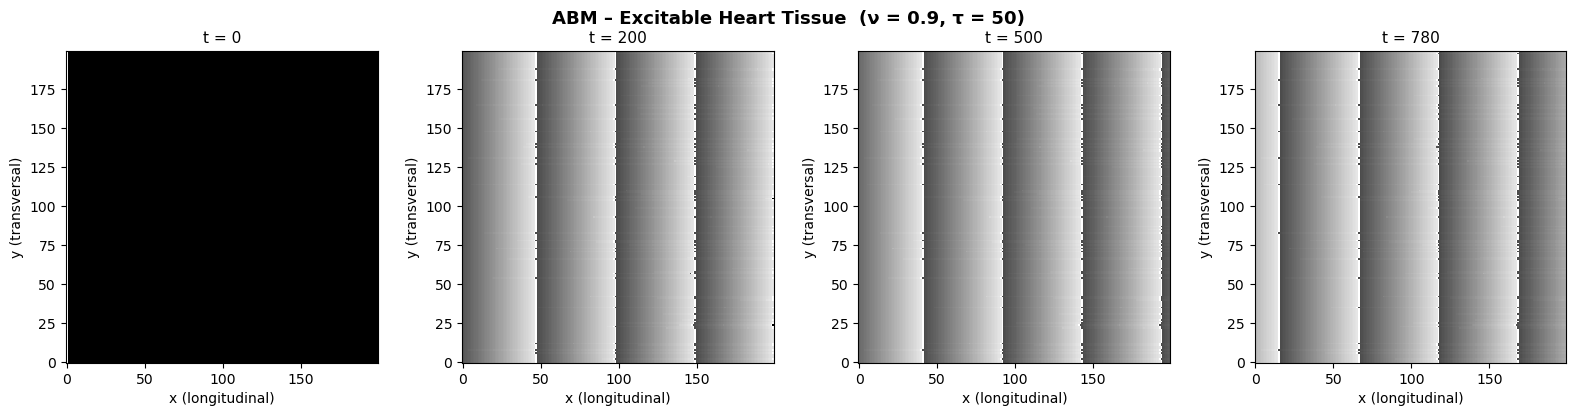


[2/3] Regime B – Intermediate (ν = 0.20)


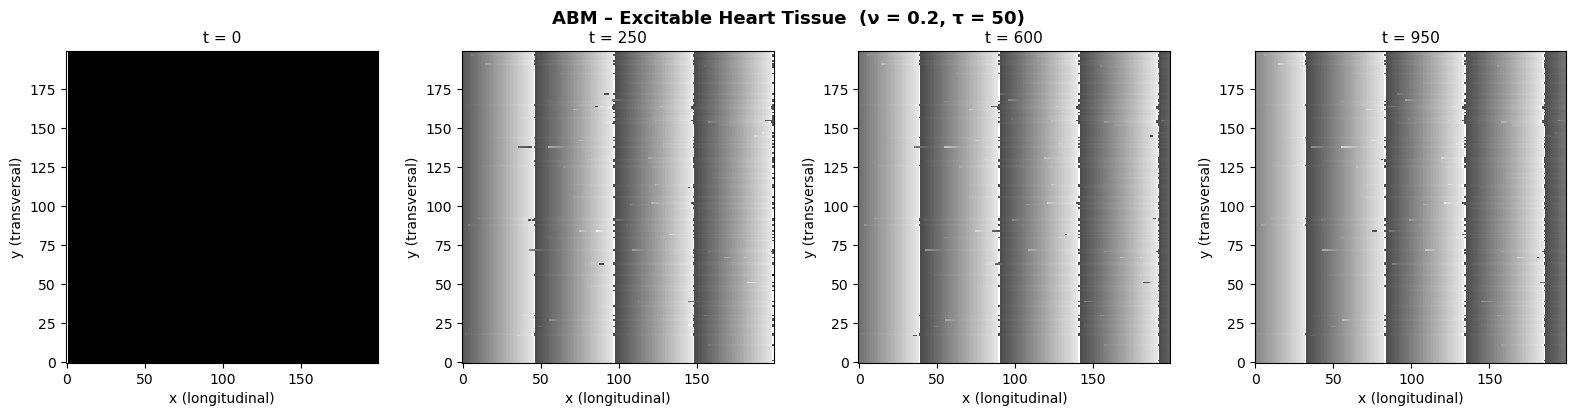


[3/3] Regime A – AF (ν = 0.10)


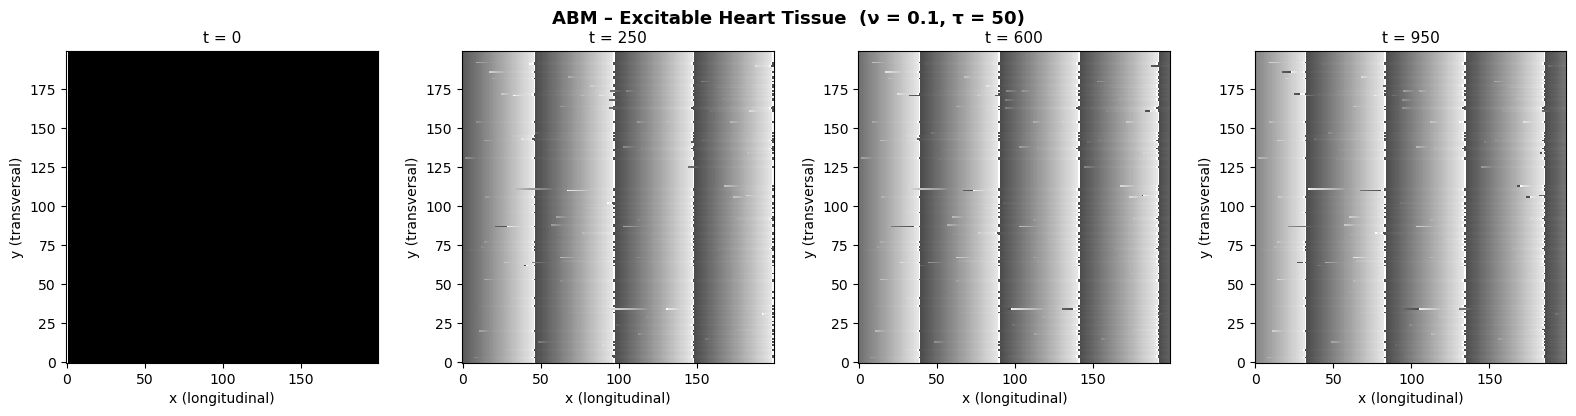


[4/4] Analytical risk curve


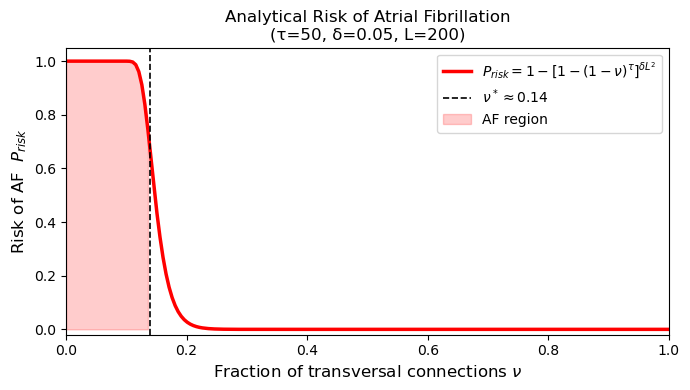

In [1]:
"""
Agent-Based Model of Excitable Media (Heart Arrhythmia)
Based on: Christensen et al., PRL 114, 028104 (2015)
         & Week 4 lecture notes (Physics of Molecular Diseases by Prof. Ala Trusina)

Model summary:
- 2D grid L x L of cardiomyocytes
- Each cell: Resting → (if excited) → Excited → Refractory(τ steps) → Resting
- Longitudinal coupling: always present
- Transversal coupling: with probability ν (ν=1: young/healthy, ν<1: aged/fibrotic)
- Dysfunctional cells: fraction δ, fail to excite with probability ε
- Pacemaker: left column, fires every T steps
- Boundary conditions: periodic (vertical), open (horizontal)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap

# ──────────────────────────────────────────────
# 1. PARAMETERS  (Table from Christensen 2015)
# ──────────────────────────────────────────────
L     = 200      # grid size (after coarse-graining b=5 from L'=1000)
TAU   = 50       # refractory period (τ' / (b·Δt') = 150ms / 3ms = 50 steps)
T     = 220      # pacemaker period  (T' / (b·Δt') = 660ms / 3ms = 220 steps)
NU    = 0.15     # fraction of transversal connections (ν < ν* ≈ 0.14 → AF)
DELTA = 0.05     # fraction of dysfunctional cells
EPS   = 0.05     # probability a dysfunctional cell fails to fire

# Cell states
RESTING    = 0
EXCITED    = 1
# Refractory states: integers 2 … TAU+1  (TAU+1 = most recently entered refractory)

RNG = np.random.default_rng(seed=42)


# ──────────────────────────────────────────────
# 2. BUILD THE SUBSTRATE
# ──────────────────────────────────────────────
def build_substrate(L, nu, delta, eps, rng):
    """
    Returns:
      transv_up[i,j]  : bool – cell (i,j) connected to (i-1,j)  [upward transversal]
      transv_dn[i,j]  : bool – cell (i,j) connected to (i+1,j)  [downward transversal]
      dysfunc[i,j]    : bool – cell is dysfunctional
    """
    # Transversal connections: each pair of vertical neighbours shares a link
    # A link exists with probability ν.  We store it on the upper cell.
    transv = rng.random((L, L)) < nu          # (i,j) has upward link to (i-1,j)
    # periodic BC vertically: wrap around
    transv_up = transv                        # (i,j) ↔ (i-1 mod L, j)
    transv_dn = np.roll(transv, -1, axis=0)  # (i,j) ↔ (i+1 mod L, j)

    dysfunc = rng.random((L, L)) < delta

    return transv_up, transv_dn, dysfunc


# ──────────────────────────────────────────────
# 3. ONE TIME-STEP UPDATE
# ──────────────────────────────────────────────
def step(state, transv_up, transv_dn, dysfunc, pacemaker_fire, rng, eps=EPS):
    """
    state: 2D array, shape (L, L)
           0         = Resting
           1         = Excited (just fired this step)
           2..TAU+1  = Refractory (countdown; TAU+1 = just became refractory)
    Returns new_state (same shape).
    """
    new_state = np.zeros_like(state)

    # ── Refractory cells: decrement counter ──
    refr_mask = state >= 2
    new_state[refr_mask] = state[refr_mask] - 1   # counts down to 1, then → 0 (Resting)

    # ── Excited cells → Refractory ──
    excit_mask = state == 1
    new_state[excit_mask] = TAU + 1                # enter refractory

    # ── Resting cells: can become excited ──
    resting_mask = state == 0

    # Which neighbours are excited?
    excit = (state == 1)

    # Longitudinal neighbours (left/right) – always coupled
    excit_left  = np.roll(excit,  1, axis=1)   # neighbour to the left
    excit_right = np.roll(excit, -1, axis=1)   # neighbour to the right
    # Open BC: no wrapping at the horizontal boundaries
    excit_left[:, 0]  = False
    excit_right[:, -1] = False

    # Transversal neighbours (up/down) – coupled with probability ν
    excit_up = np.roll(excit,  1, axis=0) & transv_up   # excited cell above + link exists
    excit_dn = np.roll(excit, -1, axis=0) & transv_dn   # excited cell below + link exists

    has_excited_neighbour = excit_left | excit_right | excit_up | excit_dn

    # Pacemaker: left column fires every T steps
    if pacemaker_fire:
        has_excited_neighbour[:, 0] = True

    # Cells that would be excited
    candidates = resting_mask & has_excited_neighbour

    # Dysfunctional cells fail with probability ε
    fail = rng.random((state.shape[0], state.shape[1])) < eps
    actually_fire = candidates & ~(dysfunc & fail)

    new_state[actually_fire] = 1  # set to Excited

    return new_state


# ──────────────────────────────────────────────
# 4. RUN SIMULATION
# ──────────────────────────────────────────────
def run_simulation(L=L, nu=NU, delta=DELTA, eps=EPS, tau=TAU, T_pace=T,
                   n_steps=1200, rng=RNG, snapshot_times=None):
    """
    Runs the ABM and returns:
      snapshots : list of (time, state_array) for requested snapshot_times
      pwave_frac: list of fraction of non-planar cells at each step (for phase diagram)
    """
    transv_up, transv_dn, dysfunc = build_substrate(L, nu, delta, eps, rng)

    state = np.zeros((L, L), dtype=np.int32)   # all Resting
    t_since_pace = 0

    if snapshot_times is None:
        snapshot_times = set()
    else:
        snapshot_times = set(snapshot_times)

    snapshots  = []
    nonplanar_frac = []

    for t in range(n_steps):
        pacemaker_fire = (t_since_pace == 0)
        state = step(state, transv_up, transv_dn, dysfunc, pacemaker_fire, rng, eps)

        t_since_pace += 1
        if t_since_pace >= T_pace:
            t_since_pace = 0

        if t in snapshot_times:
            snapshots.append((t, state.copy()))

        # Measure "non-planarity": fraction of cells NOT in the rightward-sweeping front
        # Simple proxy: std of excited cell columns (high = many wave fronts)
        excited_cols = np.where(state == 1)[1] if np.any(state == 1) else np.array([])
        nonplanar_frac.append(np.std(excited_cols) if len(excited_cols) > 0 else 0.0)

    return snapshots, nonplanar_frac


# ──────────────────────────────────────────────
# 5.  VISUALISATION HELPERS
# ──────────────────────────────────────────────
def state_to_image(state):
    """Convert state array to greyscale image: Resting=0, Excited=1, Refractory=0.3-0.9"""
    img = np.zeros_like(state, dtype=float)
    img[state == 1] = 1.0                                      # Excited → white
    refr = state >= 2
    img[refr] = 0.3 + 0.6 * (state[refr] - 2) / (TAU - 1)    # Refractory → grey gradient
    return img


def plot_snapshots(snapshots, nu, save_path=None):
    n = len(snapshots)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (t, st) in zip(axes, snapshots):
        ax.imshow(state_to_image(st), cmap='gray', vmin=0, vmax=1,
                  origin='lower', interpolation='nearest')
        ax.set_title(f't = {t}', fontsize=11)
        ax.set_xlabel('x (longitudinal)')
        ax.set_ylabel('y (transversal)')
    fig.suptitle(f'ABM – Excitable Heart Tissue  (ν = {nu}, τ = {TAU})',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()


# ──────────────────────────────────────────────
# 6. RISK CURVE  (analytical + numerical)
# ──────────────────────────────────────────────
def analytical_risk(nu_vals, tau=TAU, delta=DELTA, L=L):
    """
    P_risk = 1 − [1 − (1−ν)^τ]^(δL²)
    Equation (2) of Christensen et al. 2015
    """
    return 1 - (1 - (1 - nu_vals) ** tau) ** (delta * L ** 2)


def estimate_numerical_risk(nu_list, n_trials=10, n_steps=1500, **kwargs):
    """
    For each ν, run n_trials simulations and record fraction that develop spirals.
    "Spiral" proxy: mean(nonplanar_frac) in last half of simulation > threshold.
    """
    risks = []
    for nu in nu_list:
        spiral_count = 0
        for _ in range(n_trials):
            rng_trial = np.random.default_rng()
            _, npf = run_simulation(nu=nu, n_steps=n_steps, rng=rng_trial,
                                    snapshot_times=set(), **kwargs)
            # Proxy: large std of excited columns → multiple wave fronts
            mean_nonplanar = np.mean(npf[n_steps // 2:])
            if mean_nonplanar > 20:   # threshold (heuristic)
                spiral_count += 1
        risks.append(spiral_count / n_trials)
        print(f"  ν = {nu:.2f}  →  P_risk_numerical ≈ {risks[-1]:.2f}")
    return risks


def plot_risk_curve(save_path=None):
    nu_vals = np.linspace(0.0, 1.0, 200)
    p_analytical = analytical_risk(nu_vals)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(nu_vals, p_analytical, 'r-', lw=2.5,
            label=r'$P_{risk} = 1 - [1-(1-\nu)^\tau]^{\delta L^2}$')
    ax.axvline(x=0.14, color='k', ls='--', lw=1.2, label=r'$\nu^* \approx 0.14$')
    ax.fill_between(nu_vals[nu_vals < 0.14], p_analytical[nu_vals < 0.14],
                    alpha=0.2, color='red', label='AF region')
    ax.set_xlabel(r'Fraction of transversal connections $\nu$', fontsize=12)
    ax.set_ylabel(r'Risk of AF  $P_{risk}$', fontsize=12)
    ax.set_title('Analytical Risk of Atrial Fibrillation\n'
                 f'(τ={TAU}, δ={DELTA}, L={L})', fontsize=12)
    ax.legend(fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.02, 1.05)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()


# ──────────────────────────────────────────────
# 7. MAIN: run three regimes
# ──────────────────────────────────────────────
if __name__ == "__main__":

    print("=" * 60)
    print("ABM – Excitable Media (Christensen et al. 2015)")
    print("=" * 60)

    # ── Regime C: ν = 0.9  (healthy, planar waves) ──────────────
    print("\n[1/3] Regime C – Healthy tissue (ν = 0.9)")
    snaps_C, _ = run_simulation(nu=0.9, n_steps=800,
                                snapshot_times={0, 200, 500, 780},
                                rng=np.random.default_rng(1))
    plot_snapshots(snaps_C, nu=0.9, save_path=None)

    # ── Regime B: ν = 0.20  (occasional self-terminating spirals) ──
    print("\n[2/3] Regime B – Intermediate (ν = 0.20)")
    snaps_B, _ = run_simulation(nu=0.20, n_steps=1000,
                                snapshot_times={0, 250, 600, 950},
                                rng=np.random.default_rng(2))
    plot_snapshots(snaps_B, nu=0.20, save_path=None)

    # ── Regime A: ν = 0.10  (persistent AF, multiple spirals) ───
    print("\n[3/3] Regime A – AF (ν = 0.10)")
    snaps_A, _ = run_simulation(nu=0.10, n_steps=1000,
                                snapshot_times={0, 250, 600, 950},
                                rng=np.random.default_rng(3))
    plot_snapshots(snaps_A, nu=0.10, save_path=None)

    # ── Analytical risk curve ─────────────────────────────────────
    print("\n[4/4] Analytical risk curve")
    plot_risk_curve(save_path=None)